In [288]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.pipeline import Pipeline

In [289]:
breast_cancer = load_breast_cancer(as_frame=True)

X = breast_cancer.data
y = breast_cancer.target

In [290]:
df = breast_cancer.frame

In [291]:
print("\nHEAD")
display(df.head())

print("\nSHAPE")
display(df.shape)

print("\nCOLUMNS")
display(df.columns.tolist())

print("\nSTATISTICAL SUMMARY")
display(df.describe())


HEAD


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



SHAPE


(569, 31)


COLUMNS


['mean radius',
 'mean texture',
 'mean perimeter',
 'mean area',
 'mean smoothness',
 'mean compactness',
 'mean concavity',
 'mean concave points',
 'mean symmetry',
 'mean fractal dimension',
 'radius error',
 'texture error',
 'perimeter error',
 'area error',
 'smoothness error',
 'compactness error',
 'concavity error',
 'concave points error',
 'symmetry error',
 'fractal dimension error',
 'worst radius',
 'worst texture',
 'worst perimeter',
 'worst area',
 'worst smoothness',
 'worst compactness',
 'worst concavity',
 'worst concave points',
 'worst symmetry',
 'worst fractal dimension',
 'target']


STATISTICAL SUMMARY


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [292]:
print("\nCATEGORICAL COLUMN")
display(df.select_dtypes(include="object").columns.tolist())

print("\nNUMERICAL COLUMN")
display(df.select_dtypes(include=np.number).columns.tolist())


CATEGORICAL COLUMN


[]


NUMERICAL COLUMN


['mean radius',
 'mean texture',
 'mean perimeter',
 'mean area',
 'mean smoothness',
 'mean compactness',
 'mean concavity',
 'mean concave points',
 'mean symmetry',
 'mean fractal dimension',
 'radius error',
 'texture error',
 'perimeter error',
 'area error',
 'smoothness error',
 'compactness error',
 'concavity error',
 'concave points error',
 'symmetry error',
 'fractal dimension error',
 'worst radius',
 'worst texture',
 'worst perimeter',
 'worst area',
 'worst smoothness',
 'worst compactness',
 'worst concavity',
 'worst concave points',
 'worst symmetry',
 'worst fractal dimension',
 'target']

In [293]:
missing = df.isnull().sum()

missing_percentage = missing / len(df) * 100

missing_table = pd.DataFrame({
    "MISSING COUNT": missing,
    "MISSING PERCENTAGE": missing_percentage
})

display(missing_table)

,MISSING COUNT,MISSING PERCENTAGE
mean radius,0,0.0
mean texture,0,0.0
mean perimeter,0,0.0
mean area,0,0.0
mean smoothness,0,0.0
mean compactness,0,0.0
mean concavity,0,0.0
mean concave points,0,0.0
mean symmetry,0,0.0
mean fractal dimension,0,0.0


In [294]:
print("Total missing values: ", df.isnull().sum().sum())

Total missing values:  0


In [295]:
print("Target class")
display(breast_cancer.target_names)

Target class


array(['malignant', 'benign'], dtype='<U9')

In [296]:
print("Target distribution")
print(y.value_counts())

Target distribution
target
1    357
0    212
Name: count, dtype: int64


In [297]:
class_count = y.value_counts().sort_index()

display(
    pd.DataFrame({
        "Class": class_count.index,
        "Name": breast_cancer.target_names[class_count.index],
        "Count": class_count.values
    })
)

,Class,Name,Count
0,0,malignant,212
1,1,benign,357


In [298]:
for value, name in enumerate(breast_cancer.target_names):
  print(f"{value} -> {name}")

0 -> malignant
1 -> benign


In [299]:
X = breast_cancer.data
y = breast_cancer.target

In [300]:
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (569, 30)
y shape: (569,)


In [301]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [302]:
print(f"Training sample: {X_train.shape[0]}")
print(f"Testing sample: {X_test.shape[0]}")

Training sample: 455
Testing sample: 114


In [303]:
# scalar = StandardScaler()

# X_train_scaled = scalar.fit_transform(X_train)
# X_test_scaled = scalar.transform(X_test)

In [304]:
# print(f"Training sample: {X_train_scaled.shape}")
# print(f"Testing sample: {X_test_scaled.shape}")

In [305]:
# logistic_model = LogisticRegression(
#     max_iter=10000,
#     random_state=42
# )

In [306]:
# logistic_model.fit(X_train_scaled, y_train)

In [307]:
logistic_model = Pipeline([
    ("scalar", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('scalar', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [308]:
y_pred_train = logistic_model.predict(X_train)
y_pred = logistic_model.predict(X_test)


TRAINING:
Accuracy :  0.989010989010989
Precision:  0.9890630826259569
Recall   :  0.989010989010989
F1 score :  0.9889908435436423

TESTING:
Accuracy :  0.9824561403508771
Precision:  0.9824561403508771
Recall   :  0.9824561403508771
F1 score :  0.9824561403508771

Confusion Matrix



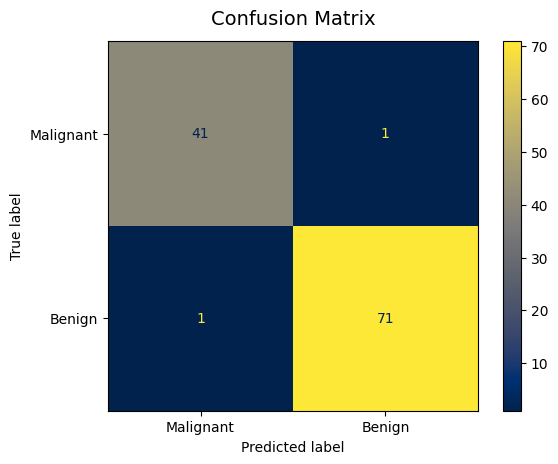

In [309]:
print("\nTRAINING:")
print("Accuracy : ", accuracy_score(y_train, y_pred_train))
print("Precision: ", precision_score(y_train, y_pred_train, average="weighted"))
print("Recall   : ", recall_score(y_train, y_pred_train, average="weighted"))
print("F1 score : ", f1_score(y_train, y_pred_train, average="weighted"))

print("\nTESTING:")
print("Accuracy : ", accuracy_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred, average="weighted"))
print("Recall   : ", recall_score(y_test, y_pred, average="weighted"))
print("F1 score : ", f1_score(y_test, y_pred, average="weighted"))

print("\nConfusion Matrix\n")
logistic_cm_disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Malignant", "Benign"],
    cmap=plt.cm.cividis
)
plt.title("Confusion Matrix", fontsize=14, pad=12)
plt.show()

In [310]:
# Lasso L1

In [311]:
lasso_model = Pipeline([
    ("scalar", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        max_iter=1000
    ))
])

lasso_model.fit(X_train, y_train)

Pipeline(steps=[('scalar', StandardScaler()),
                ('model',
                 LogisticRegression(max_iter=1000, penalty='l1',
                                    solver='liblinear'))])

In [312]:
y_pred_lasso_train = lasso_model.predict(X_train)
y_pred_lasso = lasso_model.predict(X_test)


TRAINING:
Accuracy :  0.989010989010989
Precision:  0.9890630826259569
Recall   :  0.989010989010989
F1 score :  0.9889908435436423

TESTING:
Accuracy :  0.9912280701754386
Precision:  0.9913482335976929
Recall   :  0.9912280701754386
F1 score :  0.9912054752585661

Confusion Matrix



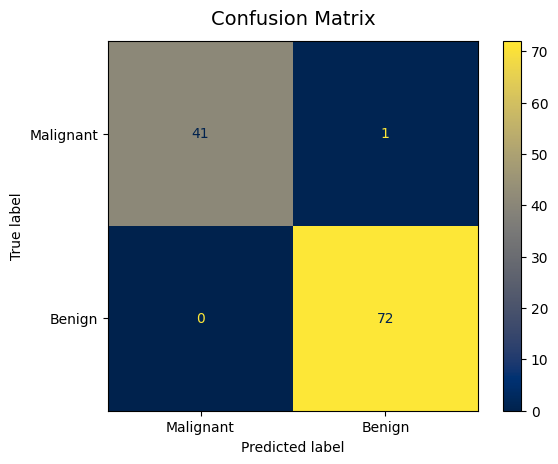

In [313]:
print("\nTRAINING:")
print("Accuracy : ", accuracy_score(y_train, y_pred_lasso_train))
print("Precision: ", precision_score(y_train, y_pred_lasso_train, average="weighted"))
print("Recall   : ", recall_score(y_train, y_pred_lasso_train, average="weighted"))
print("F1 score : ", f1_score(y_train, y_pred_lasso_train, average="weighted"))

print("\nTESTING:")
print("Accuracy : ", accuracy_score(y_test, y_pred_lasso))
print("Precision: ", precision_score(y_test, y_pred_lasso, average="weighted"))
print("Recall   : ", recall_score(y_test, y_pred_lasso, average="weighted"))
print("F1 score : ", f1_score(y_test, y_pred_lasso, average="weighted"))

print("\nConfusion Matrix\n")
logistic_cm_disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lasso,
    display_labels=["Malignant", "Benign"],
    cmap=plt.cm.cividis
)
plt.title("Confusion Matrix", fontsize=14, pad=12)
plt.show()

In [314]:
coefficients = lasso_model.named_steps["model"].coef_[0]

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "coefficient": coefficients
})

print(feature_importance)

                    feature  coefficient
0               mean radius     0.000000
1              mean texture    -0.397787
2            mean perimeter     0.000000
3                 mean area     0.000000
4           mean smoothness     0.000000
5          mean compactness     0.000000
6            mean concavity     0.000000
7       mean concave points    -0.491389
8             mean symmetry     0.000000
9    mean fractal dimension     0.081712
10             radius error    -2.168762
11            texture error     0.025218
12          perimeter error     0.000000
13               area error     0.000000
14         smoothness error    -0.199461
15        compactness error     0.698319
16          concavity error     0.000000
17     concave points error    -0.071048
18           symmetry error     0.000000
19  fractal dimension error     0.190532
20             worst radius    -1.253093
21            worst texture    -1.205341
22          worst perimeter     0.000000
23              

In [315]:
# Ridge L2

In [316]:
ridge_model = Pipeline([
    ("scalar", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l2"
    ))
])

ridge_model.fit(X_train, y_train)

Pipeline(steps=[('scalar', StandardScaler()), ('model', LogisticRegression())])

In [317]:
y_pred_ridge_train = ridge_model.predict(X_train)
y_pred_ridge = ridge_model.predict(X_test)


TRAINING:
Accuracy :  0.989010989010989
Precision:  0.9890630826259569
Recall   :  0.989010989010989
F1 score :  0.9889908435436423

TESTING:
Accuracy :  0.9824561403508771
Precision:  0.9824561403508771
Recall   :  0.9824561403508771
F1 score :  0.9824561403508771

Confusion Matrix



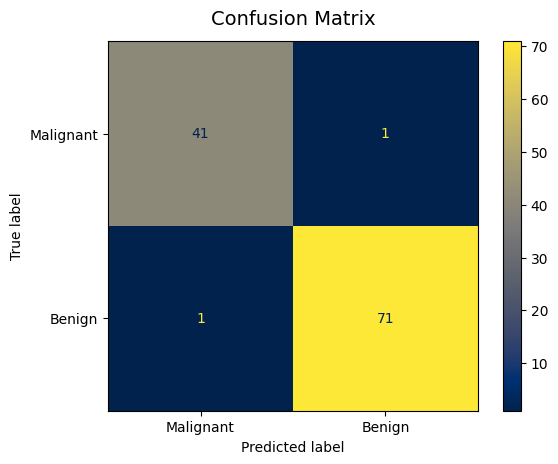

In [318]:
print("\nTRAINING:")
print("Accuracy : ", accuracy_score(y_train, y_pred_ridge_train))
print("Precision: ", precision_score(y_train, y_pred_ridge_train, average="weighted"))
print("Recall   : ", recall_score(y_train, y_pred_ridge_train, average="weighted"))
print("F1 score : ", f1_score(y_train, y_pred_ridge_train, average="weighted"))

print("\nTESTING:")
print("Accuracy : ", accuracy_score(y_test, y_pred_ridge))
print("Precision: ", precision_score(y_test, y_pred_ridge, average="weighted"))
print("Recall   : ", recall_score(y_test, y_pred_ridge, average="weighted"))
print("F1 score : ", f1_score(y_test, y_pred_ridge, average="weighted"))

print("\nConfusion Matrix\n")
logistic_cm_disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_ridge,
    display_labels=["Malignant", "Benign"],
    cmap=plt.cm.cividis
)
plt.title("Confusion Matrix", fontsize=14, pad=12)
plt.show()

In [319]:
# Cross validation for logistic regression
logistic_score = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print(f"Scores: {logistic_score}")
print(f"Scores mean: {logistic_score.mean()}")

Scores: [0.96703297 0.97802198 0.96703297 1.         0.98901099]
Scores mean: 0.9802197802197803


In [320]:
# Cross validation for logistic regression with lasso regularization
lasso_score = cross_val_score(
    lasso_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print(f"Scores: {lasso_score}")
print(f"Scores mean: {lasso_score.mean()}")

Scores: [0.95604396 0.97802198 0.96703297 0.98901099 0.98901099]
Scores mean: 0.9758241758241759


In [321]:
# Cross validation for logistic regression with ridge regularization
ridge_score = cross_val_score(
    ridge_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print(f"Scores: {ridge_score}")
print(f"Scores mean: {ridge_score.mean()}")

Scores: [0.96703297 0.97802198 0.96703297 1.         0.98901099]
Scores mean: 0.9802197802197803
